# Face Symmetry Analysis

> Why is my face not symmetrical? 🫤 … 😞 I need to know how bad it is. I can do jaw and tongue kinesitherapy exercises to try to fix it, but then I need to track my progress. I will write a Jupyter Notebook to have a quick prototype. — [Alexandre Charvier](https://github.com/alexandrecharvier95), notebook author

This notebook uses MediaPipe's Face Landmarker model to analyze facial symmetry. It detects facial landmarks, computes blendshapes, and provides a visualization of the results.

## References
- Face landmark detection guide for Python. _Google AI Edge_. https://developers.google.com/edge/mediapipe/solutions/vision/face_landmarker/python
- Face Landmarks Detection with MediaPipe Tasks. https://github.com/google-ai-edge/mediapipe-samples/blob/main/examples/face_landmarker/python/%5BMediaPipe_Python_Tasks%5D_Face_Landmarker.ipynb

## Imports and visualization utilities

To be run once.

In [1]:
import os
import sys
import warnings

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

import numpy as np

import matplotlib.pyplot as plt

import cv2


def draw_landmarks_on_image(image_rgb, detection_result):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    face_landmarks_list = detection_result.face_landmarks
    annotated_image = np.copy(image_bgr)

    # Loop through the detected faces to visualize
    for idx in range(len(face_landmarks_list)):
        face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks
    landmarks_args = [
        (
            vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
            drawing_styles.get_default_face_mesh_tesselation_style()
        ),
        (
            vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
            drawing_styles.get_default_face_mesh_contours_style()
        ),
        (
            vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
            drawing_styles.get_default_face_mesh_iris_connections_style()
        ),
        (
            vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
            drawing_styles.get_default_face_mesh_iris_connections_style()
        )
    ]
    for connections, connection_drawing_spec in landmarks_args:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks,
            connections=connections,
            landmark_drawing_spec=None,
            connection_drawing_spec=connection_drawing_spec
        )

    annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)
    return annotated_image


def camel_case_to_title_case(s):
    t = ''.join([' ' + c.upper() if c.isupper() else c for c in s]).strip()
    return t[0].upper() + t[1:]


def plot_face_blendshapes_bar_graph(blendshapes):
    # Extract the face blendshapes category names and scores
    names, scores, colors = [], [], []
    cmap = [plt.cm.tab10(i) for i in (3, 2, 0)]  # Left, Right, Neutral
    for category in blendshapes:
        name = camel_case_to_title_case(category.category_name)
        names.append(name)
        scores.append(category.score)
        colors.append(cmap[0] if name.endswith("Left")
                      else cmap[1] if name.endswith("Right")
                      else cmap[2])

    # The blendshapes are ordered in decreasing score value
    ranks = range(len(names))

    fig, ax = plt.subplots(figsize=(12, 12))
    labels = list(map(str, ranks))
    bar = ax.barh(ranks, scores, label=labels, color=colors)
    ax.set_yticks(ranks, names)
    ax.invert_yaxis()

    # Label each bar with values
    for score, patch in zip(scores, bar.patches):
        ax.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

    ax.set_xlabel("Score")
    ax.set_title("Face Blendshapes")
    plt.tight_layout()
    return ax


def imshow(image, ax=None, title=None):
    if return_ax := (ax is None):
        _, ax = plt.subplots()
    ax.imshow(image)
    ax.axis('off')
    if title:
        ax.set_title(title)
    ax.get_figure().tight_layout()
    if return_ax:
        return ax

## Creating the MediaPipe task

To be run once.

In [2]:
model_path = "models/face_landmarker_v2_with_blendshapes.task"

try:
    model_size = os.path.getsize(model_path)
    print("Model found:", model_path)
except FileNotFoundError:
    print("Model not found:", model_path)
    print("Downloading model...")

    import subprocess
    subprocess.run(["wget", "-O", model_path, "-q", "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"], check=True)
    model_size = os.path.getsize(model_path)
    print("Model downloaded")
finally:
    print(f"Size: {model_size / (2 ** 20):.3g} MB")

Model found: models/face_landmarker_v2_with_blendshapes.task
Size: 3.58 MB


In [3]:
base_options = python.BaseOptions(
    model_asset_path=model_path,
    delegate=python.BaseOptions.Delegate.CPU  # Use GPU if you have a compatible GPU and want faster inference
)

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1)

In [4]:
if sys.version_info >= (3, 13):
    warnings.warn("MediaPipe’s official wheels can occasionally experience native deadlocks on Python 3.13+ due to changes in the C-API and GIL threading behavior. Please use Python 3.12 or lower.")

if tuple(map(int, mp.__version__.split('.'))) > (0, 10, 35):
    warnings.warn("MediaPipe version bigger than 0.10.35 may cause silent failure of create_from_options(). Please use MediaPipe version 0.10.35 or lower.")

detector = vision.FaceLandmarker.create_from_options(options)

I0000 00:00:1787854814.503252 40560286 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1787854814.503738 40560286 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1787854814.551312 40560286 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787854814.552441 40560289 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787854814.558447 40560293 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Analyzing your image

Update the image path to that of your own image, which should be a JPG or PNG image in the `data` directory.

For good results:
- The image should contain a single face.
- The image should be in frontal view.
- The face should be centered.
- The face should be well-lit and not occluded.

### Loading and visualizing the image

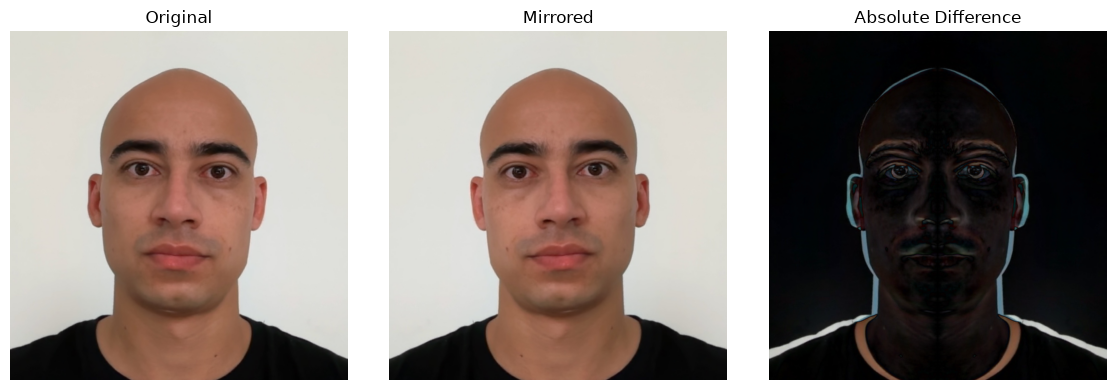

In [5]:
# Load
data_dir = "data/2026-08-27"
image_path = f"{data_dir}/face.jpg"
mp_image = mp.Image.create_from_file(image_path)

# Mirror
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
egami_rgb = cv2.flip(image_rgb, 1)
mirror_diff = cv2.absdiff(image_rgb, egami_rgb)

# Show
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
imshow(image_rgb, ax=axs[0], title="Original")
imshow(egami_rgb, ax=axs[1], title="Mirrored")
imshow(mirror_diff, ax=(ax := axs[2]), title="Absolute Difference")
ax.get_figure().savefig(f"{data_dir}/mirror_diff.png", dpi=300, bbox_inches="tight")
plt.show()

### Computing and visualizing results

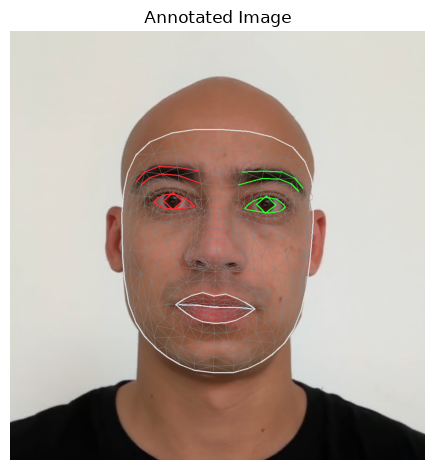

In [6]:
# Detect face landmarks
detection_result = detector.detect(mp_image)

# Draw landmarks over the image
annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
ax = imshow(annotated_image, title="Annotated Image")
ax.get_figure().savefig(f"{data_dir}/annotated.png", dpi=300, bbox_inches="tight")
plt.show()

The chart below shows the face blendshapes, which are coefficients that describe the facial expressions and the face movements. They are used in computer graphics and animation to create realistic facial animations by blending different facial expressions together. Each blendshape corresponds to a specific facial expression or movement, such as raising an eyebrow, smiling, or frowning. The coefficients indicate the intensity of each expression, allowing for smooth transitions between different facial expressions.

Red bars show shapes of left side of the face, green is for the right side, and blue is for centered shapes.

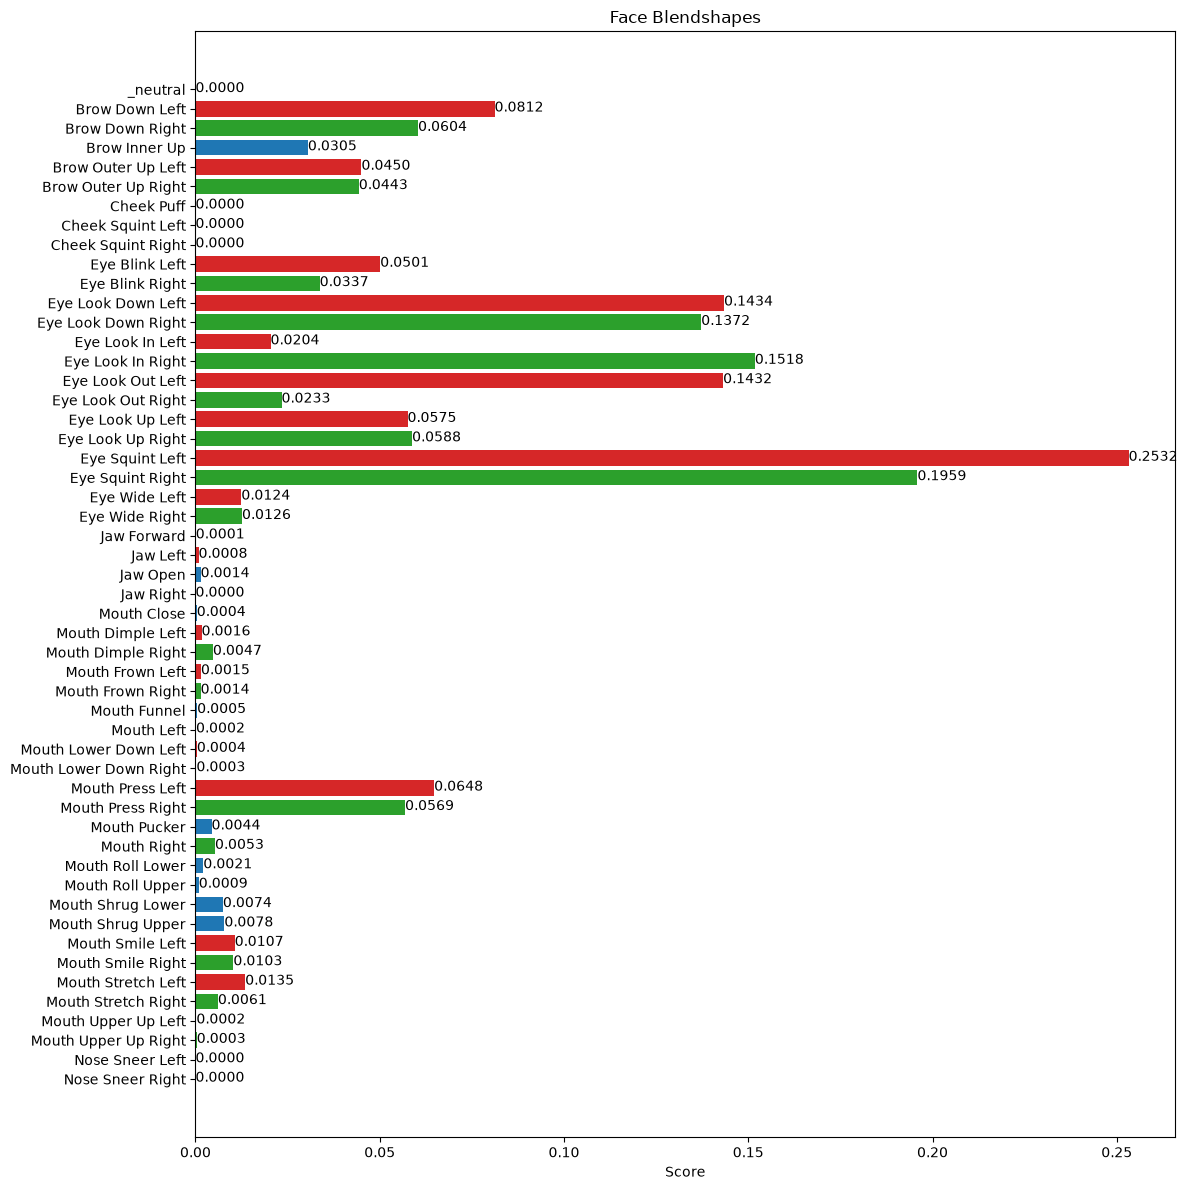

In [7]:
blendshapes = detection_result.face_blendshapes[0]
ax = plot_face_blendshapes_bar_graph(blendshapes)
ax.get_figure().savefig(f"{data_dir}/blendshapes.png", dpi=300, bbox_inches="tight")
plt.show()

### _Going further:_ Correcting orientation and position for unbiased symmetry analysis

The 4x4 facial transformation matrix below encodes absolute 3D world coordinates (translation, rotation, and scale) relative to the camera frame, rather than a simple binary flag:
- **Translation (Position):** The rightmost column of the matrix contains the actual 3D (x,y,z) coordinates of the face's center in centimeters or meters from the camera sensor. Even if you look straight ahead, unless your face is sitting at the exact optical origin (0,0,0) of the camera, those values will be non-zero numbers.
- **Rotation (Orientation):** When a face is perfectly frontal, the rotation sub-matrix (the top-left 3×3 portion) will be close to an identity matrix (1s on the diagonal, 0s elsewhere) because there is no rotation around the X, Y, or Z axes. However, scaling or perspective factors can still slightly alter those numbers.

In [8]:
print(detection_result.facial_transformation_matrixes)

[array([[ 9.9919844e-01,  3.9451376e-02, -6.8031601e-03,  1.6742403e-02],
       [-3.9513588e-02,  9.9917620e-01, -9.2676114e-03,  6.7297146e-02],
       [ 6.4319340e-03,  9.5290560e-03,  9.9993390e-01, -2.7184105e+01],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]],
      dtype=float32)]


To improve the symmetry analysis, we can use this matrix to apply a transformation to the previously detected landmarks, to correct for any translation or rotation. This will allow us to analyze the facial features in a more robust way, to compensate the fact that users can never take a perfectly frontal and centered selfie.